# W05 · Value-Based RL — Tabular Q-learning + DQN

**Platform:** Aido Rover (patrol / anomaly-response) · **Seed:** 42 · **γ = 0.99** · **Gate:** ≤100 ms

Trains value-based agents on `rl/rover_env.py` to the RL evaluation standard (return mean ± std over ≥5
seeds, learning curves with seed-variance bands). Pipeline: config (§0) → discretised **tabular Q-learning**
for intuition (§1) → **DQN** seed sweep with learning curves (§2) → full-loop evaluation vs random/scripted
references (§3) → **reward-shaping ablation** on the energy-penalty weight (§4) → inference latency (§5) →
results ledger `rl/rl_results.csv` (§6). Report: `reports/W05_RL_Foundations_Report.md`.

In [1]:
import sys, time, timeit, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, str(Path.cwd().parent))
from rl.rover_env import (RoverPatrolEnv, ACTION_NAMES, STATE_COLS, NEAR,
                          ROUGH_TERRAIN_TORQUE, LOW_SOC, STUCK_TIMEOUT)
from gymnasium.wrappers import TimeLimit
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cpu'                      # small MLP: CPU faster than GPU for DQN
DATA_DIR = Path('../data')
POL_DIR = Path('../rl/saved_policies'); POL_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR = Path('../reports/image/W05_Value_Based_RL'); IMG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# --- RL evaluation config ---
N_SEEDS        = 5
DQN_TIMESTEPS  = 80_000
TRAIN_CAP      = 2_400            # training episode cap (truncation); diversity + shorter credit horizon
EVAL_STEPS     = 9_600           # full patrol loop for final evaluation
EVAL_SEEDS     = list(range(5))  # world seeds for full-loop evaluation
GAMMA          = 0.99
EVAL_FREQ      = 20_000
N_EVAL_EP      = 3
ENERGY_WEIGHTS = [0.0, 0.05, 0.2]   # reward-shaping ablation; 0.05 = canonical (matches offline table)
CONSTRAINT_MS  = 100.0
print(f'DQN: {DQN_TIMESTEPS} steps x {N_SEEDS} seeds x {len(ENERGY_WEIGHTS)} energy-weights')

DQN: 80000 steps x 5 seeds x 3 energy-weights


## 0. Shared Helpers — Env Factory & Full-Loop Evaluation

Training uses randomised resets (fresh world seed + initial SoC ~ U(40,100) per episode) capped at 2,400
steps; evaluation uses the deterministic full 9,600-step loop. Each run offsets the env base seed by the run
seed so different seeds see different blockage layouts.

In [2]:
def make_train_env(energy_weight, run_seed):
    env = RoverPatrolEnv(randomize_reset=True, seed=SEED + run_seed * 10_000,
                         energy_weight=energy_weight)
    return Monitor(TimeLimit(env, max_episode_steps=TRAIN_CAP))

def make_eval_env(energy_weight, world_seed):
    env = RoverPatrolEnv(randomize_reset=False, seed=world_seed, energy_weight=energy_weight)
    return Monitor(TimeLimit(env, max_episode_steps=EVAL_STEPS))

def eval_full_loop(predict_fn, energy_weight=0.05, eval_seeds=EVAL_SEEDS):
    """Evaluate a policy on the full loop over several world seeds.
    predict_fn(obs)->action. Returns dict with per-episode return, length, action counts, terminal SoC."""
    rets, lens, term_soc = [], [], []
    act_counts = np.zeros(5, dtype=float)
    for ws in eval_seeds:
        env = RoverPatrolEnv(randomize_reset=False, seed=ws, energy_weight=energy_weight)
        obs, info = env.reset()
        G, t, done = 0.0, 0, False
        while not done and t < EVAL_STEPS:
            a = int(predict_fn(obs)); act_counts[a] += 1
            obs, r, term, trunc, info = env.step(a)
            G += r; t += 1; done = term or trunc
        rets.append(G); lens.append(t); term_soc.append(float(obs[STATE_COLS.index('battery_soc')]))
    return dict(ret_mean=np.mean(rets), ret_std=np.std(rets), len_mean=np.mean(lens),
                rets=np.array(rets), act_frac=act_counts / act_counts.sum(),
                term_soc=np.array(term_soc))

# reference policies (defined once, reused across sections)
def random_predict(obs, rng=np.random.default_rng(SEED)):
    return int(rng.integers(0, 4))              # no-abort random baseline

_stuck = {'c': 0}
def scripted_blind(obs):
    # DEPLOYABLE rule policy: sees only the observation (no ground-truth label), so it can navigate
    # (reroute/slow) but can never alert on an anomaly.
    soc, tmean = obs[5], obs[0]
    main_d, branch_d = obs[7], obs[8]
    halted = main_d < 2.0                        # halted ≈ blocked within HALT_CLEARANCE
    full_block = main_d < NEAR and branch_d < NEAR
    _stuck['c'] = _stuck['c'] + 1 if (halted and full_block) else 0
    if soc < LOW_SOC:            return 4
    if _stuck['c'] >= STUCK_TIMEOUT: return 4
    if halted and full_block:   return 3
    if main_d < NEAR and branch_d >= NEAR: return 2
    if tmean > ROUGH_TERRAIN_TORQUE: return 1
    return 0

_stuck_e = {'c': 0}
def expert_aware(obs, label):
    # PRIVILEGED generation-time expert: also alerts on the ground-truth label. Not deployable (needs the
    # label), but its return is the ceiling a sensor-only imitator (BC) can aspire to.
    soc, tmean = obs[5], obs[0]
    main_d, branch_d = obs[7], obs[8]
    halted = main_d < 2.0; full_block = main_d < NEAR and branch_d < NEAR
    _stuck_e['c'] = _stuck_e['c'] + 1 if (halted and full_block) else 0
    if soc < LOW_SOC:            return 4
    if _stuck_e['c'] >= STUCK_TIMEOUT: return 4
    if halted and full_block:   return 3
    if label == 1:              return 3         # privileged label-aware alert
    if main_d < NEAR and branch_d >= NEAR: return 2
    if tmean > ROUGH_TERRAIN_TORQUE: return 1
    return 0

def eval_expert_aware(eval_seeds=EVAL_SEEDS):
    rets, lens = [], []
    for ws in eval_seeds:
        _stuck_e['c'] = 0
        env = RoverPatrolEnv(randomize_reset=False, seed=ws); obs, info = env.reset()
        G, t, done = 0.0, 0, False
        while not done and t < EVAL_STEPS:
            obs, r, term, trunc, info = env.step(expert_aware(obs, info.get('label', 0)))
            G += r; t += 1; done = term or trunc
        rets.append(G); lens.append(t)
    return np.mean(rets), np.std(rets), np.mean(lens)

def event_stats(predict_fn, label_aware=False, eval_seeds=EVAL_SEEDS):
    """Event-conditioned action statistics: how a policy responds to the situations it faces
    (demonstrates reactive competence directly, rather than inferring it from a scalar return)."""
    anom = alert_anom = normal = false_alert = sb = rero_sb = rough = slow_rough = 0
    if label_aware: _stuck_e['c'] = 0
    else: _stuck['c'] = 0
    for ws in eval_seeds:
        env = RoverPatrolEnv(randomize_reset=False, seed=ws); obs, info = env.reset()
        t, done = 0, False
        while not done and t < EVAL_STEPS:
            lbl = info.get('label', 0)
            a = predict_fn(obs, lbl) if label_aware else predict_fn(obs)
            main_d, branch_d, tmean = obs[7], obs[8], obs[0]
            if lbl == 1: anom += 1; alert_anom += (a == 3)
            else: normal += 1; false_alert += (a == 3)
            if main_d < NEAR and branch_d >= NEAR: sb += 1; rero_sb += (a == 2)
            if tmean > ROUGH_TERRAIN_TORQUE: rough += 1; slow_rough += (a == 1)
            obs, r, term, trunc, info = env.step(a); t += 1; done = term or trunc
    return dict(p_alert_anom=alert_anom / max(anom, 1), fa_per_1k=false_alert / max(normal, 1) * 1e3,
                p_rero_singleblock=rero_sb / max(sb, 1), p_slow_rough=slow_rough / max(rough, 1))
print('helpers ready')

helpers ready


## 1. Tabular Q-learning (intuition)

A deliberately small discretisation to build intuition — **96 states** from the observation alone (no
privileged info, so the tabular agent sees exactly what DQN's network sees): SoC (3 bins) × torque_mean
(2: high-slip terrain) × **torque_std (2: fault signature)** × main-blocked (2) × branch-blocked (2). The
`torque_std` axis matters: slip faults show up as torque variability, not mean (terrain confounds the mean —
wet grass baselines above 30 Nm), so without it the table structurally cannot represent *detect → raise-alert*.
The `torque_std` threshold is taken from the offline data (separating normal from fault windows).

In [3]:
# data-driven torque_std threshold: midpoint of normal vs anomaly medians on the offline table
_tt = pd.read_csv(DATA_DIR / 'rover_transitions.csv')
ts_norm = _tt.loc[_tt.actual_label == 0, 's_torque_std'].median()
ts_anom = _tt.loc[_tt.actual_label == 1, 's_torque_std'].median()
TSTD_THRESH = float((ts_norm + ts_anom) / 2)
print(f'torque_std medians  normal={ts_norm:.3f}  anomaly={ts_anom:.3f}  -> threshold={TSTD_THRESH:.3f}')

def discretize(obs):
    soc, tmean, tstd, main_d, branch_d = obs[5], obs[0], obs[2], obs[7], obs[8]
    b_soc = 0 if soc < LOW_SOC else (1 if soc < 50 else 2)
    b_tm  = int(tmean > ROUGH_TERRAIN_TORQUE)
    b_ts  = int(tstd > TSTD_THRESH)
    b_mb  = int(main_d < NEAR)
    b_bb  = int(branch_d < NEAR)
    return ((((b_soc * 2 + b_tm) * 2 + b_ts) * 2 + b_mb) * 2 + b_bb)   # 0..95
N_STATES = 96

torque_std medians  normal=0.535  anomaly=2.765  -> threshold=1.650


In [4]:
def train_qlearning(run_seed, n_episodes=250, alpha=0.1, gamma=GAMMA,
                    eps0=1.0, eps_min=0.05, eps_decay=0.99):
    rng = np.random.default_rng(run_seed)
    env = RoverPatrolEnv(randomize_reset=True, seed=SEED + run_seed * 10_000)
    Q = np.zeros((N_STATES, 5))
    eps = eps0; curve = []
    for ep in range(n_episodes):
        obs, _ = env.reset(); s = discretize(obs); G = 0.0; done = False; t = 0
        while not done and t < TRAIN_CAP:
            a = int(rng.integers(0, 5)) if rng.random() < eps else int(np.argmax(Q[s]))
            obs, r, term, trunc, _ = env.step(a); ns = discretize(obs)
            Q[s, a] += alpha * (r + gamma * np.max(Q[ns]) * (not term) - Q[s, a])
            s = ns; G += r; t += 1; done = term or trunc
        curve.append(G); eps = max(eps_min, eps * eps_decay)
    return Q, np.array(curve)

t0 = time.time()
q_curves, q_tables = [], []
for rs in range(N_SEEDS):
    Q, curve = train_qlearning(rs)
    q_tables.append(Q); q_curves.append(curve)
q_curves = np.array(q_curves)
np.save(POL_DIR / 'qtable_seed0.npy', q_tables[0])
print(f'tabular Q-learning: {N_SEEDS} seeds in {time.time()-t0:.1f}s')

# greedy policy from the mean Q-table, evaluated on the full loop
Q_mean = np.mean(q_tables, axis=0)
q_eval = eval_full_loop(lambda o: int(np.argmax(Q_mean[discretize(o)])))
print(f'tabular Q greedy full-loop return {q_eval["ret_mean"]:.1f} ± {q_eval["ret_std"]:.1f}')

tabular Q-learning: 5 seeds in 27.4s


tabular Q greedy full-loop return -320.4 ± 734.8


### 1.1 Tabular learning curve

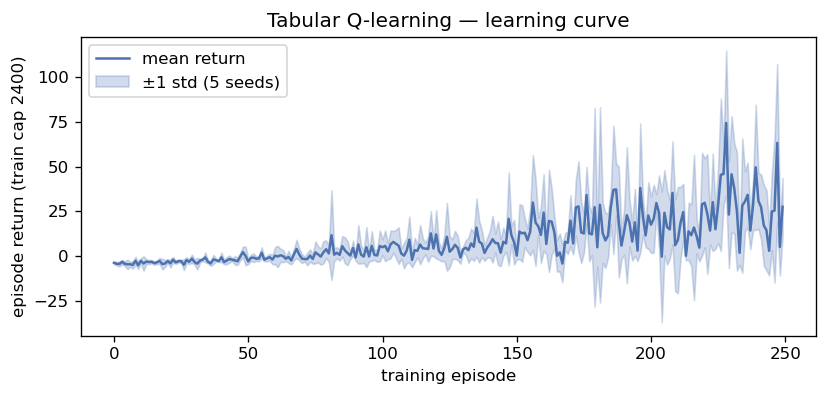

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.4))
m, sd = q_curves.mean(0), q_curves.std(0)
x = np.arange(len(m))
ax.plot(x, m, color='#4C72B0', label='mean return')
ax.fill_between(x, m - sd, m + sd, alpha=0.25, color='#4C72B0', label='±1 std (5 seeds)')
ax.set_xlabel('training episode'); ax.set_ylabel('episode return (train cap 2400)')
ax.set_title('Tabular Q-learning — learning curve'); ax.legend()
plt.tight_layout(); plt.savefig(IMG_DIR / 'qlearning_curve.png', bbox_inches='tight'); plt.show()

## 2. DQN (Stable-Baselines3)

`MlpPolicy` [64, 64], γ = 0.99, on the full 9-D observation. Trained under a 2,400-step truncation (surfaced
as `truncated`, so SB3 bootstraps at the cap rather than treating it as a terminal state). `N_SEEDS` seeds;
an `EvalCallback` logs the deterministic evaluation return every `EVAL_FREQ` steps to build the seed-banded
learning curve. Trained models are cached under `rl/saved_policies/` and skipped on re-run.

In [6]:
def train_dqn(energy_weight, run_seed, timesteps=DQN_TIMESTEPS):
    tag = f'dqn_ew{energy_weight}_s{run_seed}'
    zip_path = POL_DIR / f'{tag}.zip'
    log_dir = POL_DIR / f'evallog_{tag}'
    npz = log_dir / 'evaluations.npz'
    if zip_path.exists() and npz.exists():
        d = np.load(npz)
        return DQN.load(zip_path, device=DEVICE), d['timesteps'], d['results'].mean(1)
    env = make_train_env(energy_weight, run_seed)
    eval_env = make_eval_env(energy_weight, world_seed=777)
    # cap eval horizon shorter during training for speed; final table uses full loop separately
    eval_env = Monitor(TimeLimit(RoverPatrolEnv(randomize_reset=False, seed=777,
                                                energy_weight=energy_weight), max_episode_steps=TRAIN_CAP))
    cb = EvalCallback(eval_env, best_model_save_path=None, log_path=str(log_dir),
                      eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL_EP, deterministic=True, verbose=0)
    model = DQN('MlpPolicy', env, learning_rate=5e-4, buffer_size=50_000, learning_starts=2_000,
                batch_size=128, gamma=GAMMA, train_freq=4, gradient_steps=1,
                target_update_interval=1_000, exploration_fraction=0.3, exploration_final_eps=0.05,
                policy_kwargs=dict(net_arch=[64, 64]), device=DEVICE, seed=run_seed, verbose=0)
    model.learn(timesteps, callback=cb, progress_bar=False)
    model.save(zip_path)
    d = np.load(npz)
    return model, d['timesteps'], d['results'].mean(1)

# Train the canonical energy_weight=0.05 seed sweep first (this is the main DQN result)
t0 = time.time()
dqn_main, dqn_curves = [], []
for rs in range(N_SEEDS):
    model, ts, curve = train_dqn(0.05, rs)
    dqn_main.append(model); dqn_curves.append(curve)
ts_axis = ts
dqn_curves = np.array(dqn_curves)
print(f'DQN (ew=0.05) {N_SEEDS} seeds in {(time.time()-t0)/60:.1f} min')

DQN (ew=0.05) 5 seeds in 0.0 min


### 2.1 DQN learning curve (with random / scripted references)

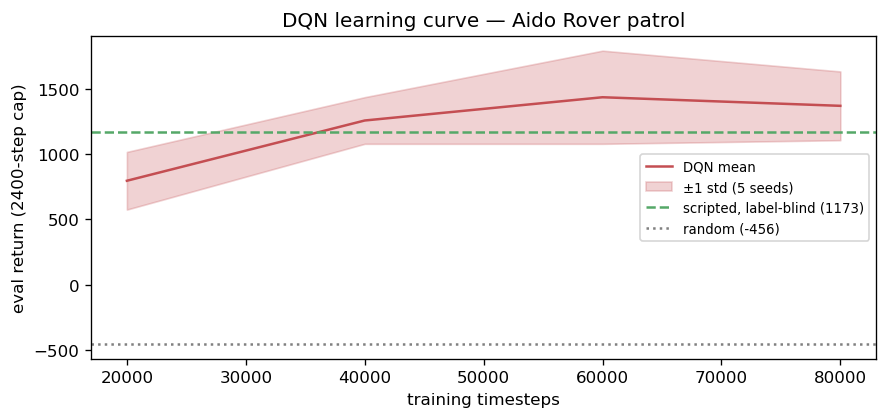

~episodes trained ≈ 33 (train cap 2400)
eval return  first 797  ->  last 1371  (Δ last-vs-prev -66)


In [7]:
# reference returns on the SAME 2400-cap eval env used by the callback
def ref_return_2400(predict_fn, seed=777):
    env = RoverPatrolEnv(randomize_reset=False, seed=seed)
    obs, _ = env.reset(); G, t, done = 0.0, 0, False
    while not done and t < TRAIN_CAP:
        obs, r, term, trunc, _ = env.step(int(predict_fn(obs))); G += r; t += 1; done = term or trunc
    return G
_stuck['c'] = 0
r_rand = np.mean([ref_return_2400(lambda o: random_predict(o)) for _ in range(5)])
r_scr  = ref_return_2400(scripted_blind)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
m, sd = dqn_curves.mean(0), dqn_curves.std(0)
ax.plot(ts_axis, m, color='#C44E52', label='DQN mean')
ax.fill_between(ts_axis, m - sd, m + sd, alpha=0.25, color='#C44E52', label='±1 std (5 seeds)')
ax.axhline(r_scr, ls='--', color='#55A868', label=f'scripted, label-blind ({r_scr:.0f})')
ax.axhline(r_rand, ls=':', color='gray', label=f'random ({r_rand:.0f})')
ax.set_xlabel('training timesteps'); ax.set_ylabel('eval return (2400-step cap)')
ax.set_title('DQN learning curve — Aido Rover patrol'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(IMG_DIR / 'dqn_curve.png', bbox_inches='tight'); plt.show()
# budget check: 80k steps at ~2400-step training episodes is only ~33 episodes; is the curve still rising?
print(f'~episodes trained ≈ {DQN_TIMESTEPS // TRAIN_CAP} (train cap {TRAIN_CAP})')
print(f'eval return  first {m[0]:.0f}  ->  last {m[-1]:.0f}  (Δ last-vs-prev {m[-1]-m[-2]:+.0f})')

## 3. Full-Loop Evaluation — Value-Based vs References

All policies evaluated on the deterministic full 9,600-step loop over 5 world seeds. Two reference points
bracket the learned agents: the **scripted, label-blind** policy is what a rule-based system can do at
deployment (it navigates — reroute/slow — but never sees the anomaly label, so it cannot alert on faults),
and the **expert, label-aware** policy additionally alerts using the ground-truth label (privileged, not
deployable — its return is the ceiling a sensor-only imitator could reach). DQN is evaluated per trained seed
then aggregated. Note the ± columns describe different variances: world-seed variance for the fixed policies,
train-seed(+world) variance for DQN — total return is not directly comparable across policies with very
different episode lengths, which §3.1 addresses with event-conditioned statistics.

In [8]:
rows = []
_stuck['c'] = 0
for name, fn in [('random (no-abort)', lambda o: random_predict(o)),
                 ('scripted, label-blind', scripted_blind),
                 ('tabular Q (greedy)', lambda o: int(np.argmax(Q_mean[discretize(o)])))]:
    e = eval_full_loop(fn)
    rows.append([name, e['ret_mean'], e['ret_std'], e['len_mean']])

# DQN: evaluate each seed's model on full loop, aggregate across seeds
dqn_seed_ret, dqn_seed_len = [], []
for model in dqn_main:
    e = eval_full_loop(lambda o: model.predict(o, deterministic=True)[0])
    dqn_seed_ret.append(e['ret_mean']); dqn_seed_len.append(e['len_mean'])
rows.append(['DQN (5-seed)', float(np.mean(dqn_seed_ret)), float(np.std(dqn_seed_ret)),
             float(np.mean(dqn_seed_len))])
# privileged ceiling
em, esd, elen = eval_expert_aware()
rows.append(['expert, label-aware', em, esd, elen])
eval_table = pd.DataFrame(rows, columns=['policy', 'return_mean', 'return_std', 'len_mean']).round(2)
eval_lookup = eval_table.set_index('policy')
print(eval_table.to_string(index=False))

               policy  return_mean  return_std  len_mean
    random (no-abort)      -606.64      239.01    3942.0
scripted, label-blind      4072.02      516.10    9529.6
   tabular Q (greedy)      -320.42      734.84    3472.4
         DQN (5-seed)      1562.68      517.08    4643.6
  expert, label-aware     12199.24      736.02    9367.2


### 3.1 Event-Conditioned Action Statistics

Total return conflates competence with episode length. The direct evidence of *what a policy learned* is how
it responds to the situations it faces: does it alert when an anomaly is present, avoid false alarms, reroute
at a single blockage, and slow on rough terrain? These separate reactive competence (detection) from
navigational competence (reroute) — the distinction that explains the DQN result.

In [9]:
ev_rows = []
for name, fn, la in [('scripted, label-blind', scripted_blind, False),
                     ('DQN (seed 0)', lambda o: int(dqn_main[0].predict(o, deterministic=True)[0]), False),
                     ('expert, label-aware', expert_aware, True)]:
    s = event_stats(fn, label_aware=la)
    ev_rows.append([name, s['p_alert_anom'], s['fa_per_1k'], s['p_rero_singleblock'], s['p_slow_rough']])
ev_table = pd.DataFrame(ev_rows, columns=['policy', 'P(alert|anomaly)', 'false_alerts_per_1k_normal',
                                          'P(reroute|single-block)', 'P(slow|rough)']).round(3)
print(ev_table.to_string(index=False))
print('\nDQN alerts on a majority of anomalies but with a very high false-alarm rate, and almost never')
print('reroutes or slows -> it learned to over-alert, not to navigate; the reroute failure drives it into')
print('full-block dead ends (all eval episodes end via stuck-timeout at 79-89% SoC).')

               policy  P(alert|anomaly)  false_alerts_per_1k_normal  P(reroute|single-block)  P(slow|rough)
scripted, label-blind             0.004                       1.069                    1.000          0.909
         DQN (seed 0)             0.563                     213.316                    0.027          0.019
  expert, label-aware             1.000                       0.762                    0.850          0.606

DQN alerts on a majority of anomalies but with a very high false-alarm rate, and almost never
reroutes or slows -> it learned to over-alert, not to navigate; the reroute failure drives it into
full-block dead ends (all eval episodes end via stuck-timeout at 79-89% SoC).


## 4. Reward-Shaping Ablation — Energy-Penalty Weight

Retrain DQN at energy weights `{0.0, 0.05, 0.2}` (0.05 = canonical), five seeds each, comparing the action-
usage profile and terminal SoC — not just return. With only 5 seeds the return differences are within seed
variance (see §4 output) and the action-profile changes are non-monotonic, so the ablation is read as
*suggestive* rather than a clean dose-response; the one robust observation is the flat terminal SoC, which
§4's note explains.

In [10]:
ablation = {}
t0 = time.time()
for ew in ENERGY_WEIGHTS:
    if ew == 0.05:
        models = dqn_main
    else:
        models = [train_dqn(ew, rs)[0] for rs in range(N_SEEDS)]
    # aggregate action profile + terminal SoC + return across seeds on the full loop (eval at ew=0.05 reward
    # for a common return scale, but action profile reflects the policy trained under ew)
    act_fracs, term_socs, rets = [], [], []
    for m in models:
        e = eval_full_loop(lambda o, mm=m: mm.predict(o, deterministic=True)[0], energy_weight=0.05)
        act_fracs.append(e['act_frac']); term_socs.append(e['term_soc'].mean()); rets.append(e['ret_mean'])
    ablation[ew] = dict(models=models, act_frac=np.mean(act_fracs, 0),
                        term_soc=np.mean(term_socs), ret_mean=np.mean(rets), ret_std=np.std(rets))
print(f'ablation trained in {(time.time()-t0)/60:.1f} min (0.05 reused from §2)')
for ew in ENERGY_WEIGHTS:
    a = ablation[ew]
    print(f'ew={ew:<5} return {a["ret_mean"]:7.1f}±{a["ret_std"]:5.1f} | term_SoC {a["term_soc"]:5.1f}% | '
          f'action% ' + ' '.join(f'{ACTION_NAMES[i][:4]}:{a["act_frac"][i]*100:4.1f}' for i in range(5)))

ablation trained in 3.0 min (0.05 reused from §2)
ew=0.0   return  1208.2±672.7 | term_SoC  81.6% | action% cont:31.7 slow:51.3 rero: 2.4 rais:14.6 retu: 0.0
ew=0.05  return  1562.7±517.1 | term_SoC  81.9% | action% cont:36.6 slow:39.4 rero: 5.8 rais:18.2 retu: 0.0
ew=0.2   return  1544.6±678.5 | term_SoC  81.3% | action% cont:37.3 slow:47.7 rero: 2.9 rais:12.1 retu: 0.0


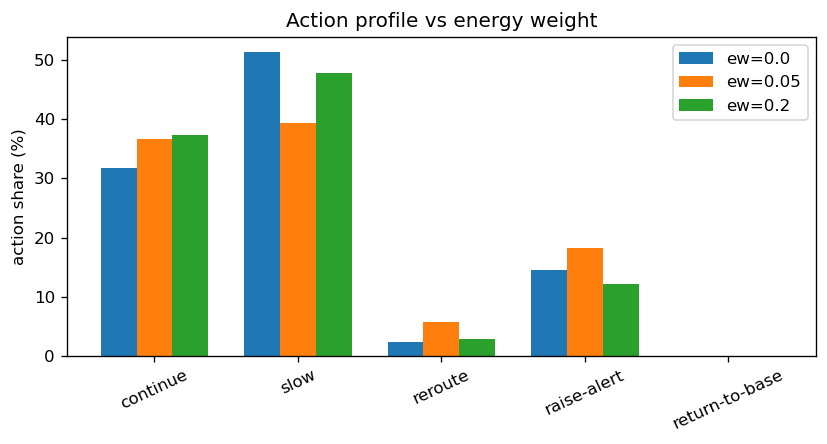

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.8))
x = np.arange(5); w = 0.25
for i, ew in enumerate(ENERGY_WEIGHTS):
    ax.bar(x + (i - 1) * w, ablation[ew]['act_frac'] * 100, width=w, label=f'ew={ew}')
ax.set_xticks(x); ax.set_xticklabels([ACTION_NAMES[i] for i in range(5)], rotation=25)
ax.set_ylabel('action share (%)'); ax.set_title('Action profile vs energy weight'); ax.legend()
plt.tight_layout(); plt.savefig(IMG_DIR / 'shaping_ablation.png', bbox_inches='tight'); plt.show()

## 5. Inference Latency

A trained policy is an MLP (or table lookup) at inference — single-sample latency is measured with `timeit`
and judged against the 100 ms Aido Rover patrol gate. Policy inference is far below the gate; the RL cost is
in training, not deployment.

In [12]:
obs0 = RoverPatrolEnv(randomize_reset=False, seed=0).reset()[0]
model0 = dqn_main[0]
n_rep = 1000
t_dqn = timeit.timeit(lambda: model0.predict(obs0, deterministic=True), number=n_rep) / n_rep * 1e3
t_tab = timeit.timeit(lambda: int(np.argmax(Q_mean[discretize(obs0)])), number=n_rep) / n_rep * 1e3
print(f'DQN     single-obs inference: {t_dqn:.4f} ms  -> {"PASS" if t_dqn < CONSTRAINT_MS else "FAIL"} (<{CONSTRAINT_MS}ms)')
print(f'Tabular single-obs lookup   : {t_tab:.4f} ms  -> PASS')

DQN     single-obs inference: 0.0760 ms  -> PASS (<100.0ms)
Tabular single-obs lookup   : 0.0021 ms  -> PASS


## 6. Results Ledger → `rl/rl_results.csv`

In [13]:
rl_csv = Path('../rl/rl_results.csv')
def ledger_row(**kw):
    base = dict(week=5, task='rover_patrol', platform='Aido Rover', gamma=GAMMA,
                timesteps='', n_seeds=N_SEEDS, eval_horizon=EVAL_STEPS, eval_policy='deterministic',
                energy_weight=0.05, shaping_low_soc=True, alert_clears_block=False,
                latency_ms='', constraint_ms=CONSTRAINT_MS, verdict='', notes='')
    base.update(kw); return base

def EV(name, col): return round(float(eval_lookup.loc[name, col]), 2)
rows = []
rows.append(ledger_row(policy='random_no_abort', timesteps=0, n_seeds=len(EVAL_SEEDS),
                       return_mean=EV('random (no-abort)','return_mean'),
                       return_std=EV('random (no-abort)','return_std'),
                       len_mean=EV('random (no-abort)','len_mean'), notes='reference'))
rows.append(ledger_row(policy='scripted_label_blind', timesteps=0, n_seeds=len(EVAL_SEEDS),
                       return_mean=EV('scripted, label-blind','return_mean'),
                       return_std=EV('scripted, label-blind','return_std'),
                       len_mean=EV('scripted, label-blind','len_mean'),
                       notes='deployable rule policy (navigates, cannot alert on faults)'))
rows.append(ledger_row(policy='expert_label_aware', timesteps=0, n_seeds=len(EVAL_SEEDS),
                       return_mean=EV('expert, label-aware','return_mean'),
                       return_std=EV('expert, label-aware','return_std'),
                       len_mean=EV('expert, label-aware','len_mean'),
                       notes='privileged ceiling (uses ground-truth label; not deployable)'))
rows.append(ledger_row(policy='tabular_Q', timesteps='250 ep', return_mean=round(q_eval['ret_mean'],2),
                       return_std=round(q_eval['ret_std'],2), len_mean=EV('tabular Q (greedy)','len_mean'),
                       latency_ms=round(t_tab,4), verdict='PASS', notes='96-state discretization, intuition only'))
for ew in ENERGY_WEIGHTS:
    a = ablation[ew]
    rows.append(ledger_row(policy='DQN', timesteps=DQN_TIMESTEPS, energy_weight=ew,
                           return_mean=round(a['ret_mean'],2), return_std=round(a['ret_std'],2),
                           len_mean='', latency_ms=round(t_dqn,4), verdict='PASS',
                           notes=('canonical' if ew==0.05 else 'shaping ablation')))
rl_df = pd.DataFrame(rows)
cols = ['week','policy','task','platform','timesteps','n_seeds','gamma','eval_horizon','eval_policy',
        'energy_weight','shaping_low_soc','alert_clears_block','return_mean','return_std','len_mean',
        'latency_ms','constraint_ms','verdict','notes']
rl_df = rl_df[cols]
rl_df.to_csv(rl_csv, index=False)
print('wrote', rl_csv)
rl_df[['policy','energy_weight','return_mean','return_std','latency_ms','verdict','notes']]

wrote ../rl/rl_results.csv


,policy,energy_weight,return_mean,return_std,latency_ms,verdict,notes
0,random_no_abort,0.05,-606.64,239.01,,,reference
1,scripted_label_blind,0.05,4072.02,516.10,,,"deployable rule policy (navigates, cannot aler..."
2,expert_label_aware,0.05,12199.24,736.02,,,privileged ceiling (uses ground-truth label; n...
3,tabular_Q,0.05,-320.42,734.84,0.0021,PASS,"96-state discretization, intuition only"
4,DQN,0.00,1208.23,672.73,0.076,PASS,shaping ablation
5,DQN,0.05,1562.68,517.08,0.076,PASS,canonical
6,DQN,0.20,1544.62,678.55,0.076,PASS,shaping ablation
